In [1]:
import fiona
import geopandas as gpd
import shapely
import os
os.environ['GDAL_DATA'] = os.environ['CONDA_PREFIX'] + r'/Library/share/gdal'
os.environ['PROJ_LIB'] = os.environ['CONDA_PREFIX'] + r'/Library/share'

In [7]:
# data_dir=r'E://data/boundaries/'
data_dir=r'C://Users/kerrie/Documents/02_LocalData/boundaries/'

# I grabbed all the resolutions to see the differences
# I suspect the lowest res will be fine
# shapefiles = ['cb_2023_us_state_500k.shp',
#               'cb_2023_us_state_5m.shp',
#               'cb_2023_us_state_20m.shp'] 
shapefile='cb_2023_us_state_20m.shp'

# this subset of states is based on the geographic areas 
# used for wildfire coordination https://gacc.nifc.gov/index.php              
# I would prefer to use fire climate region 14 (https://www.nwcg.gov/publications/pms425-1/12-fire-climate-regions)
# but would need to find the shapefile for that. idk if it exists  
# states_list = ['TX','OK','AR','LA','MS','AL','GA','FL','TN','KY','SC','NC','VA'] 
# states_list = ['LA','MS','AR','TN','MO','KY','IL','IN','WI','MI'] 
states_list = ['MS'] 


# load and subset lowest res census bureau shapefile

In [8]:
# ifile=2
# layers=fiona.listlayers(data_dir+'orig/'+shapefiles[ifile])
layers=fiona.listlayers(data_dir+'orig/'+shapefile)

layers

['cb_2023_us_state_20m']

In [12]:
# USstates=gpd.read_file(data_dir+'orig/'+shapefiles[ifile],layer=layers[0])
USstates=gpd.read_file(data_dir+'orig/'+shapefile,layer=layers[0])
USstates=USstates.loc[USstates['STUSPS'].isin(states_list)].reset_index(drop=True)
print(USstates.crs)


# reprojecting
USstates=USstates.to_crs("EPSG:4326")
print(USstates.crs)
USstates

EPSG:4269
EPSG:4326


,STATEFP,STATENS,GEOIDFQ,GEOID,STUSPS,NAME,LSAD,ALAND,AWATER,geometry
0,28,01779790,0400000US28,28,MS,Mississippi,00,121533540877,3914738613,"POLYGON ((-91.62136 31.26781, -91.56419 31.261..."


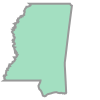

In [16]:
# study_area=shapely.ops.unary_union(USstates.geometry)
study_area = USstates.loc[0]['geometry']
study_area

In [17]:
study_area.geom_type

'Polygon'

I think the lowest resolution boundaries will be fine for subsetting model and observational data

# write the study area shape to a shapefile

In [18]:
# write the study area shape to a new shapefile
schema={'geometry':study_area.geom_type,
        'properties':{'id':'int'}}

with fiona.open(data_dir+'MS_bounds.shp','w','ESRI Shapefile',schema,crs=fiona.crs.from_epsg(4326)) as f:
    f.write({'geometry':shapely.geometry.mapping(study_area),'properties':{'id':0}})

In [19]:
test=gpd.read_file(data_dir+'MS_bounds.shp')#,layer=layers[0])
test

,id,geometry
0,0,"POLYGON ((-91.62136 31.26781, -91.56419 31.261..."


<Axes: >

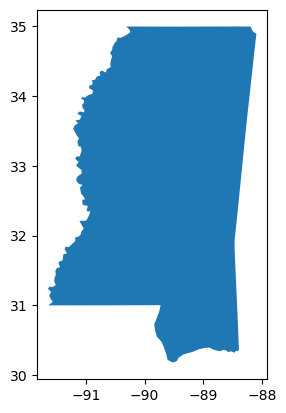

In [20]:
test.plot()

In [19]:
print(test.crs)

EPSG:4326


# write rectangular bounding box to shapefile

for crude subsetting of large data files

Polygon


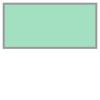

In [20]:
boundbox = study_area.envelope
print(boundbox.geom_type)
boundbox

In [21]:
# write to new shapefile
schema={'geometry':'Polygon',
        'properties':{'id':'int'}}

with fiona.open(data_dir+'study_area_bounding_box.shp','w','ESRI Shapefile',schema,crs=fiona.crs.from_epsg(4326)) as f:
    f.write({'geometry':shapely.geometry.mapping(boundbox),'properties':{'id':0}})